In [1]:
import os
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from torchvision import transforms
from torchvision.models import resnet50, mobilenet_v2, densenet121

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import confusion_matrix, accuracy_score

In [2]:
DATA_DIR = r"D:\majorprojectdataset\ISL_CSLRT_Corpus\ISL_CSLRT_Corpus\Frames_Word_Level"

IMG_SIZE = 160
BATCH_SIZE = 16

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [3]:
val_tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [4]:
classes = sorted([d for d in os.listdir(DATA_DIR)
                  if os.path.isdir(os.path.join(DATA_DIR, d))])

label_map = {cls: idx for idx, cls in enumerate(classes)}
idx2word = {v: k for k, v in label_map.items()}
NUM_CLASSES = len(classes)

paths, labels = [], []

for cls in classes:
    folder = os.path.join(DATA_DIR, cls)
    for f in os.listdir(folder):
        if f.lower().endswith((".jpg",".png",".jpeg")):
            paths.append(os.path.join(folder, f))
            labels.append(label_map[cls])

In [5]:
class ISLDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels, transform):
        self.paths = paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), self.labels[i]

In [6]:
test_loader = DataLoader(
    ISLDataset(paths, labels, val_tfm),
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [7]:
models = {}

# =========================
# 🔹 ResNet50
# =========================
from torchvision.models import resnet50

model_resnet = resnet50()

in_features = model_resnet.fc.in_features
model_resnet.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

model_resnet.load_state_dict(torch.load("resnet50_model.pth", map_location=DEVICE))
model_resnet.to(DEVICE)
model_resnet.eval()

models["ResNet50"] = model_resnet


# =========================
# 🔹 MobileNetV2
# =========================
from torchvision.models import mobilenet_v2

model_mobile = mobilenet_v2()

in_features = model_mobile.classifier[1].in_features
model_mobile.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

model_mobile.load_state_dict(torch.load("mobilenet_model.pth", map_location=DEVICE))
model_mobile.to(DEVICE)
model_mobile.eval()

models["MobileNetV2"] = model_mobile


# =========================
# 🔹 DenseNet121
# =========================
from torchvision.models import densenet121

model_dense = densenet121()

in_features = model_dense.classifier.in_features
model_dense.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(in_features, NUM_CLASSES)
)

model_dense.load_state_dict(torch.load("densenet_model.pth", map_location=DEVICE))
model_dense.to(DEVICE)
model_dense.eval()

models["DenseNet121"] = model_dense


print("✅ All models loaded successfully")

✅ All models loaded successfully



🔍 Evaluating ResNet50


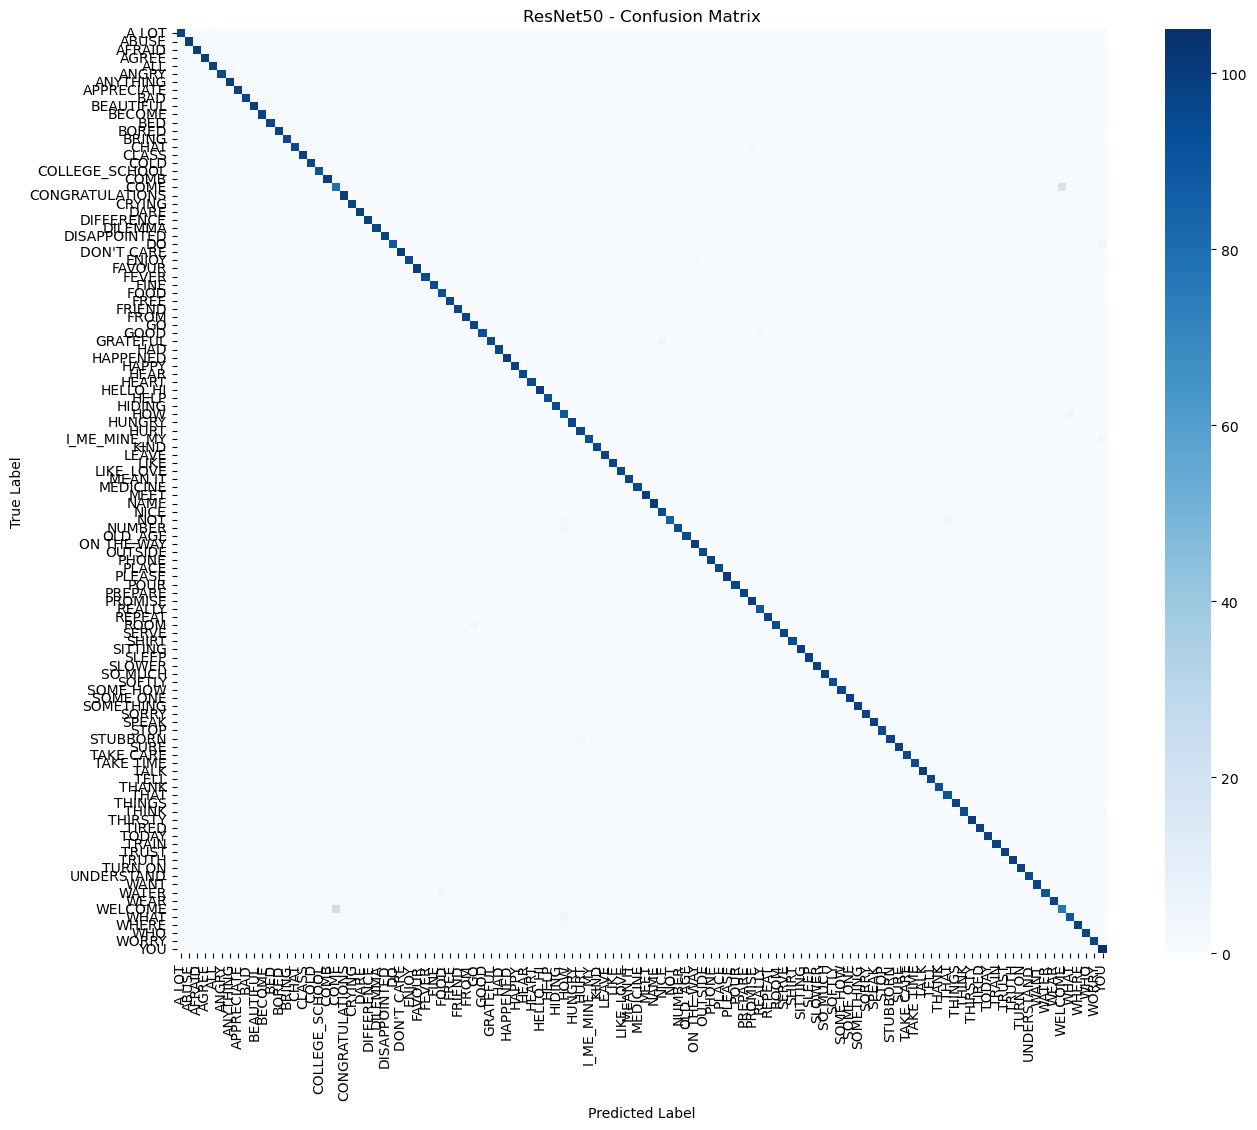


🔍 Evaluating MobileNetV2


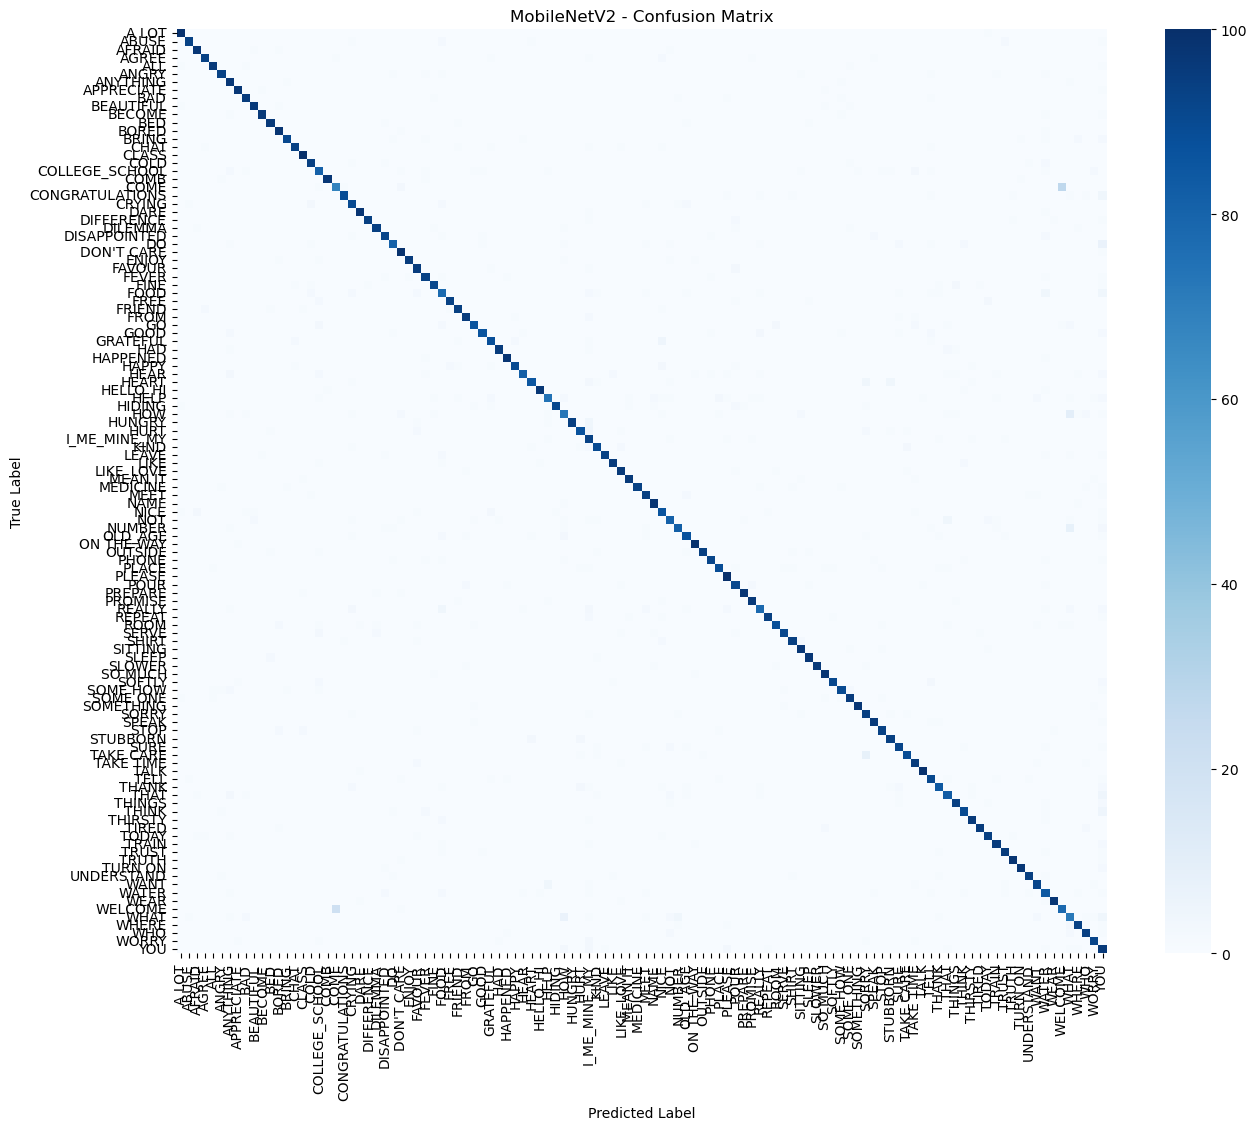


🔍 Evaluating DenseNet121


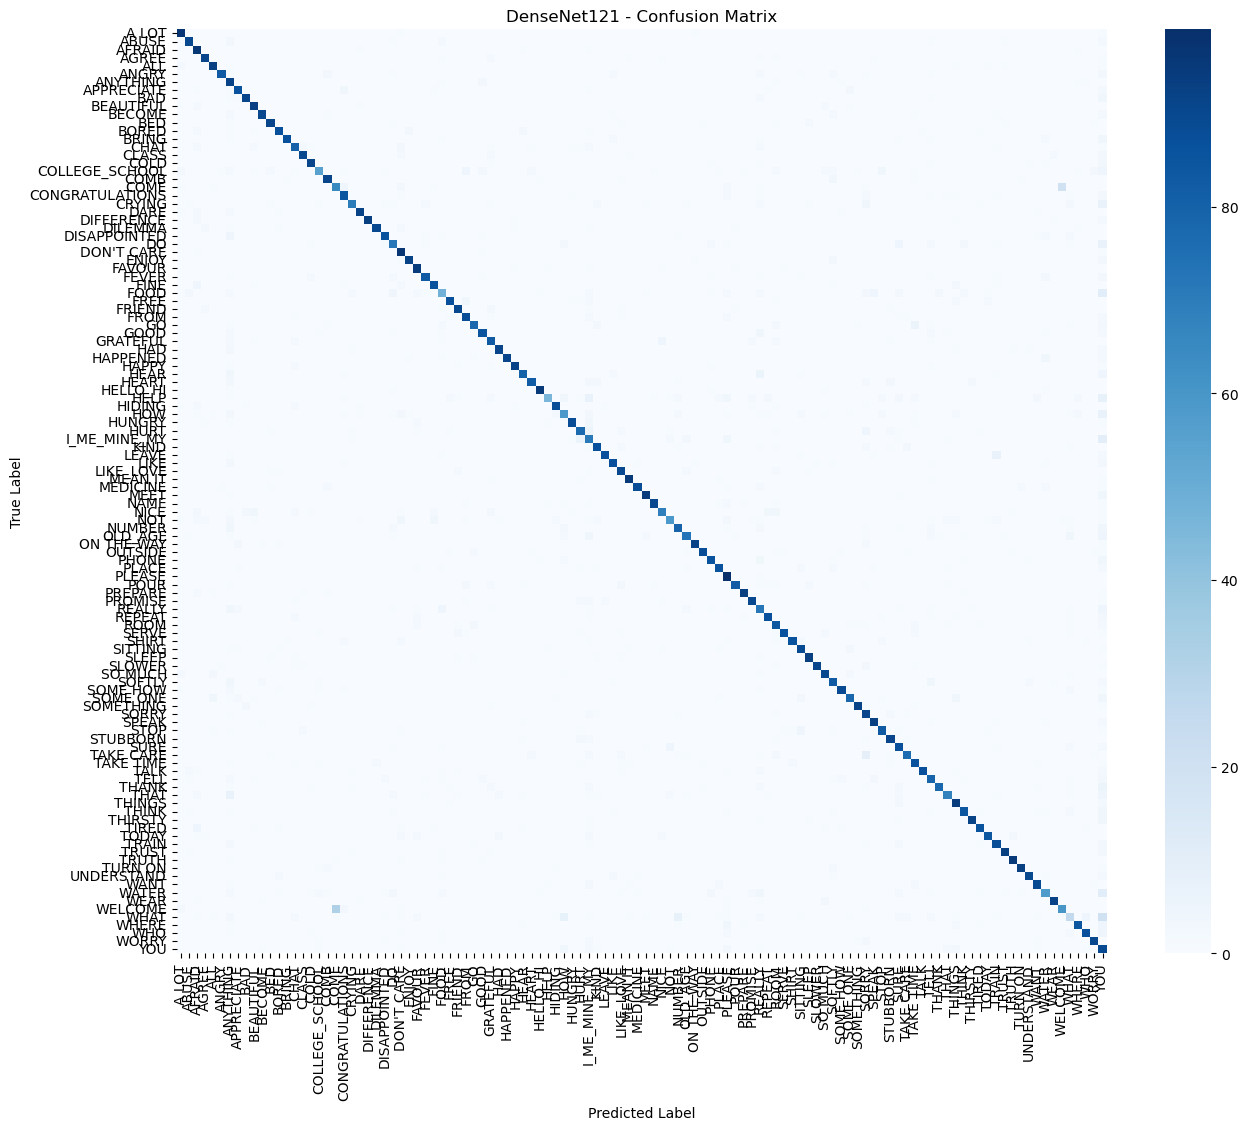

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    print(f"\n🔍 Evaluating {name}")

    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            outputs = model(imgs)
            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 🔥 Plot with class names
    plt.figure(figsize=(15, 12))
    sns.heatmap(
        cm,
        cmap="Blues",
        xticklabels=classes,
        yticklabels=classes
    )

    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.xticks(rotation=90)
    plt.yticks(rotation=0)

    # Save image
    plt.savefig(f"{name}_confusion_matrix.png", bbox_inches='tight')

    plt.show()

In [9]:
import numpy as np
from sklearn.metrics import confusion_matrix

for name, model in models.items():
    print(f"\n🔍 {name} - Per Class Accuracy")

    all_preds = []
    all_labels = []

    model.eval()

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

            outputs = model(imgs)
            preds = outputs.argmax(1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # 🔥 Per-class accuracy = diagonal / row sum
    class_acc = cm.diagonal() / cm.sum(axis=1)

    for i, acc in enumerate(class_acc):
        print(f"{idx2word[i]} → {acc:.2f}")


🔍 ResNet50 - Per Class Accuracy
A LOT → 0.98
ABUSE → 0.94
AFRAID → 0.99
AGREE → 0.95
ALL → 0.95
ANGRY → 0.94
ANYTHING → 0.95
APPRECIATE → 0.92
BAD → 0.94
BEAUTIFUL → 0.97
BECOME → 0.94
BED → 0.92
BORED → 0.97
BRING → 0.90
CHAT → 0.91
CLASS → 0.96
COLD → 0.91
COLLEGE_SCHOOL → 0.86
COMB → 0.97
COME → 0.71
CONGRATULATIONS → 0.91
CRYING → 0.87
DARE → 0.94
DIFFERENCE → 0.94
DILEMMA → 0.96
DISAPPOINTED → 0.93
DO → 0.82
DON'T CARE → 0.99
ENJOY → 0.94
FAVOUR → 0.96
FEVER → 0.91
FINE → 0.89
FOOD → 0.81
FREE → 0.91
FRIEND → 0.97
FROM → 0.95
GO → 0.92
GOOD → 0.88
GRATEFUL → 0.88
HAD → 0.92
HAPPENED → 0.95
HAPPY → 0.95
HEAR → 0.84
HEART → 0.90
HELLO_HI → 0.99
HELP → 0.73
HIDING → 0.91
HOW → 0.67
HUNGRY → 0.91
HURT → 0.90
I_ME_MINE_MY → 0.91
KIND → 0.89
LEAVE → 0.94
LIKE → 0.93
LIKE_LOVE → 0.96
MEAN IT → 0.98
MEDICINE → 0.92
MEET → 0.96
NAME → 1.00
NICE → 0.91
NOT → 0.78
NUMBER → 0.88
OLD_AGE → 0.88
ON THE WAY → 0.99
OUTSIDE → 0.93
PHONE → 0.92
PLACE → 0.95
PLEASE → 1.00
POUR → 0.95
PREPARE → 0.95

In [9]:
import numpy as np

# Example confusion matrix (replace with yours)
cm = np.array([[50, 2, 1],
               [3, 45, 2],
               [0, 2, 48]])

# Accuracy
accuracy = np.trace(cm) / np.sum(cm)

# Precision, Recall, F1 (per class)
precision = np.diag(cm) / np.sum(cm, axis=0)
recall = np.diag(cm) / np.sum(cm, axis=1)
f1_score = 2 * (precision * recall) / (precision + recall)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1_score)

Accuracy: 0.934640522875817
Precision: [0.94339623 0.91836735 0.94117647]
Recall: [0.94339623 0.9        0.96      ]
F1 Score: [0.94339623 0.90909091 0.95049505]
